In [32]:
!pip install statsmodels

In [70]:
import pandas as pd
from pickle import dump
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

# Proyecto de series de tiempo alternativo

## Sistema de predicción de ventas

Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

### Paso 1: Carga del conjunto de datos

In [55]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv')
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


Tenemos que pasar la columna date a datetime

In [56]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.asfreq('MS')  

In [57]:
df.shape

(12, 1)

Debido a que trabajaremos con todos los datos, y ya son numericos, no escalaremos ni haremos un analisis de las variables.  ya podemos generar una serie temporal con dos dimensiones, la temporal y el dato que queremos analizar y predecir, es decir las ventas

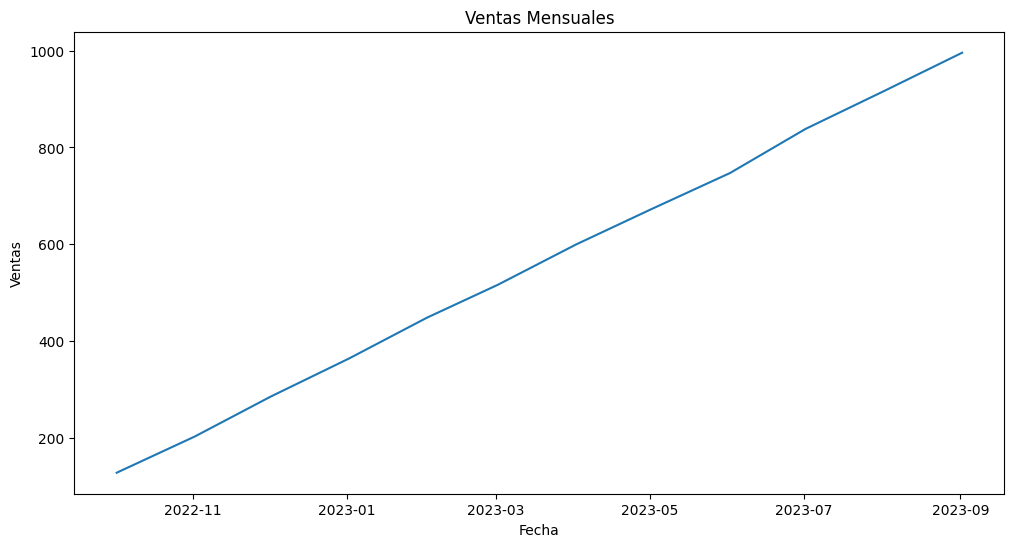

In [58]:
plt.figure(figsize=(12,6))
plt.plot(df['sales'])
plt.title('Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.show()

Siendo la frecuencia mensual, podemos decir que la venta han ido en aumento mes a mes, es decir el tensor es mensual

## Tendencia

In [59]:
df.shape

(12, 1)

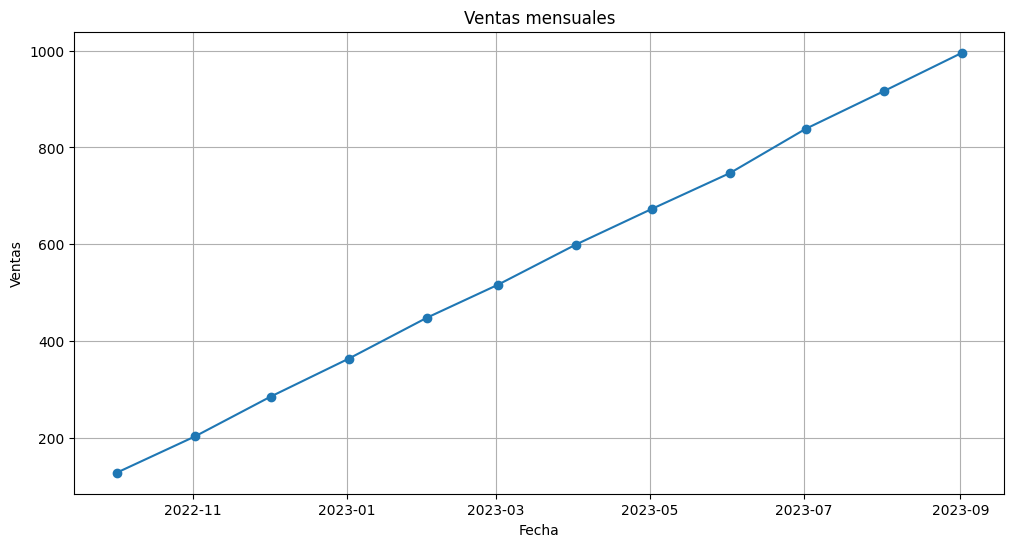

In [60]:
plt.figure(figsize=(12,6))
plt.plot(df['sales'], marker='o')
plt.title('Ventas mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

La tendencia muestra un ligero crecimiento general, no es lineal pero se nota creciente

## Es estacionaria?

In [61]:
result_adf = adfuller(df['sales'])
print('ADF Statistic:', result_adf[0])
print('p-value:', result_adf[1])

ADF Statistic: 0.5315455243035676
p-value: 0.9858010072349015


Como el p-value es mayor a 0.05 podemos decir que no es estacionaria

## Variabilidad

con el anterior grafico tambien podemos notar que hay fluctuaciones en los meses 

## Separamos train y test

In [62]:
train = df.iloc[:-3]
test = df.iloc[-3:]

In [63]:
model = ARIMA(train['sales'], order=(1, 1, 1))
model_fit = model.fit()
model_fit.summary()

c:\Users\nahue\Documents\4GEEKS\najuvgz-intro-ml\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\nahue\Documents\4GEEKS\najuvgz-intro-ml\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\nahue\Documents\4GEEKS\najuvgz-intro-ml\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                    9
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -29.077
Date:                Sat, 26 Jul 2025   AIC                             64.154
Time:                        11:46:05   BIC                             64.392
Sample:                    10-01-2022   HQIC                            62.547
                         - 06-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   5.38e-05   1.86e+04      0.000       1.000       1.000
ma.L1         -0.9886      0.777     -1.273      0.203      -2.511       0.534
sigma2        34.4372      0.023   1525.351      0.000      34.393      34.481
===================================================================================
Ljung-Box (L1) (Q):                   1.36   Jarque-Bera (JB):                 0.89
Prob(Q):                              0.24   Prob(JB):                         0.64
Heteroskedasticity (H):               1.00   Skew:                            -0.71
Prob(H) (two-sided):                  1.00   Kurtosis:                         2.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.15e+19. Standard errors may be unstable.
"""

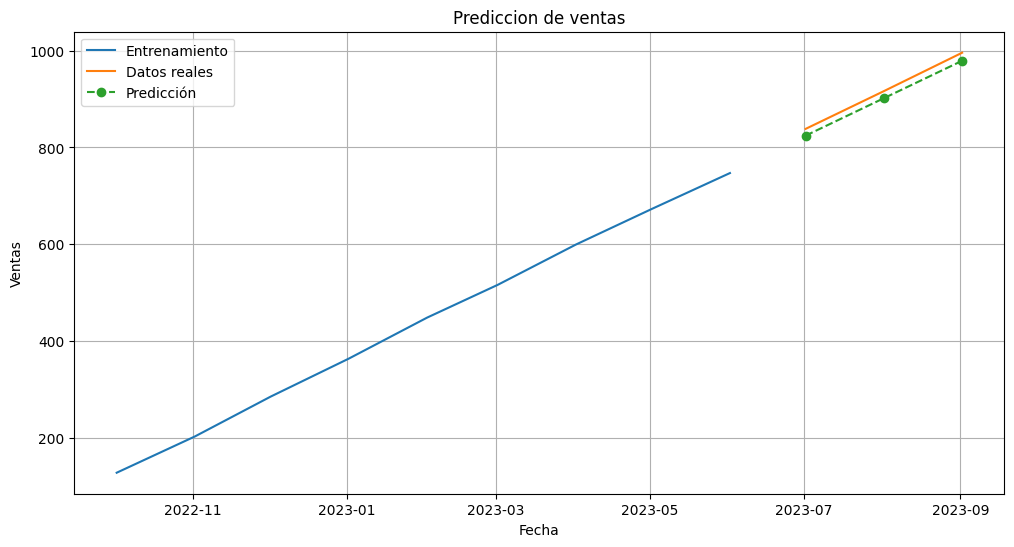

In [68]:

forecast = model_fit.forecast(steps=3)



plt.figure(figsize=(12,6))
plt.plot(train.index, train['sales'], label='Entrenamiento')
plt.plot(test.index, test['sales'], label='Datos reales')
plt.plot(test.index, forecast, label='Predicción', linestyle='--', marker='o')
plt.title('Prediccion de ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


## Conclusion
Nuestro modelo ARIMA ha sido capaz de predecir los siguientes 3 meses con bastante precision

In [71]:
with open('modelo_time_series.pkl', 'wb') as file:
    dump(model, file)